$ \textbf{Aluna:}$ Alessandra da Silva Dias Malizia   
$ \textbf{Data:}$ 08/07/2025

# Trabalho da P2

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import scipy.stats as stats
import seaborn as sns

In [2]:
rng = np.random.default_rng(seed=4)

# Questão 1
Desenvolva os cálculos para determinar os estimadores (de MV ou MM, você
escolhe) do parâmetro θ para cada uma das distribuições discretas abaixo:

## a) Gamma
Gama(x; k=2, θ), com $$ f_X(x; k,\theta) = \frac{x^{k-1}\,e^{-x/\theta}}{\Gamma(k)\,\theta^k},\quad k>0,\ \theta>0,\ x>0 $$

![Gráfico bonito](img/1a.jpg)

## b) Exponencial
Exponencial, com $$ f_X(x; \theta) = \frac{1}{\theta}\,e^{-x/\theta},\quad \theta>0,\ x>0 $$

![Gráfico bonito](img/1b.jpg)

## c) Log-Normal
Log-Normal, com $$ f_X(x; \mu=0,\ \theta) = \frac{1}{x\sqrt{2\pi}\,\theta}\,e^{-\frac{1}{2\theta^2}(\ln x - \mu)^2},\quad \theta>0,\ x>0 $$

![Gráfico bonito](img/1c.jpg)

# Questão 2
Escolha uma dessas distribuições. Desenvolva os cálculos para determinar as
propriedades amostrais do estimador de θ para a distribuição que você selecionou:

## a) Viés

![Gráfico bonito](img/2a.jpg)

## b) MSE

![Gráfico bonito](img/2b.jpg)

## c) Consistência

![Gráfico bonito](img/2c.jpg)

## d) Eficiência Assintótica [TODO]

# Questão 3
Vamos agora analisar empiricamente como essas propriedades variam com o
tamanho da amostra. Para isso, assuma um valor populacional para o parâmetro θ e
crie 100 amostras, AA(n)i, i=1,...,n com n=200

Denote por $ \hat{\theta}_{i,j}$ o valor estimado de θ na sub-amostra i, i=1,...,100 usando as primeiras
j observações, j=1,...,200.

In [3]:
# amostragem
n, n_samples = 200, 100
θ = 2
samples = np.zeros((n_samples, n))

for i in range(n_samples):
    samples[i] = rng.gamma(shape=2, scale=θ, size=n)    

In [4]:
def calcula_estimador(samples, sample_size):
    '''
    Calcula o estimador desenvolvido pelo método dos momentos para cada amostra, utilizando sub-amostras de tamanho sample_size.
    Retorna um vetor de tamanho n_samples
    '''
    if sample_size > samples.shape[1] or sample_size <= 0:
        return np.full(samples.shape[0], np.nan)
    return np.mean(samples[:,:sample_size], axis=1)/2

In [5]:
estimativas = np.zeros((n_samples, 200))
for j in range(1,201):
    estimativas[:,j-1] = calcula_estimador(samples, j)

In [6]:
estimativas.shape

(100, 200)

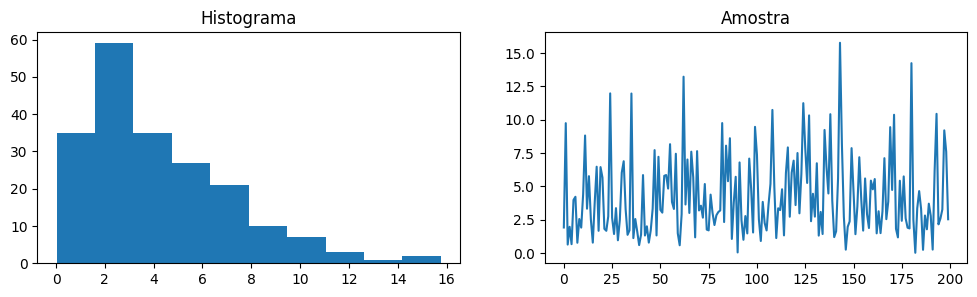

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12,3))

ax[0].hist(samples[0])
ax[0].set_title('Histograma')
ax[1].plot(np.arange(n), samples[0])
ax[1].set_title('Amostra')
plt.show()

## item a)
Defina o viés empírico usando j observações de cada sub-amostra por,
$$
\text{Viés}_{\text{empírico}}(\hat{\theta}_{j}) = \frac{1}{100}\sum_{i=1}^{100} \hat{\theta}_{i,j} - \theta,
$$

e faça um gráfico representando a evolução de $Viés_{empírico}(\hat{\theta}_{i,j})$ contra j.
Comente o resultado com relação ao apresentado na questão 3.

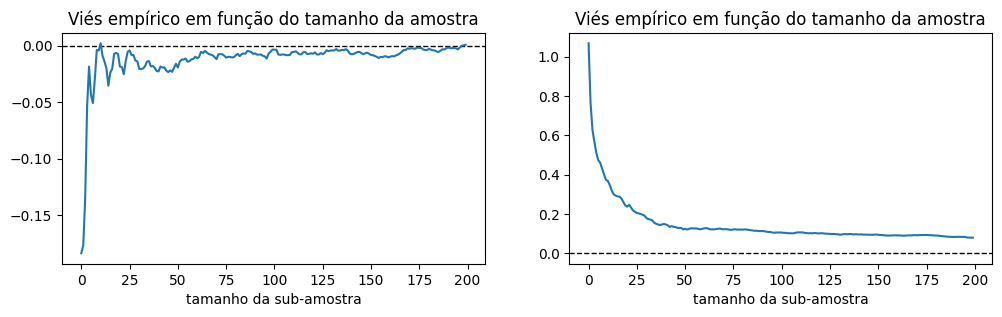

In [8]:
vies_empirico = np.sum(estimativas, axis=0)/100 -  θ

fig, ax = plt.subplots(1,2,figsize=(12,3))
ax[0].axhline(y=0, color='black', linestyle='--', linewidth=1)
ax[0].plot(np.arange(len(vies_empirico)), vies_empirico)
ax[0].set_title('Viés empírico em função do tamanho da amostra')
ax[0].set_xlabel('tamanho da sub-amostra')

vies_empirico = np.sum(np.abs(estimativas - θ), axis=0)/100
ax[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
ax[1].plot(np.arange(len(vies_empirico)), vies_empirico)
ax[1].set_title('Viés empírico em função do tamanho da amostra')
ax[1].set_xlabel('tamanho da sub-amostra')
plt.show()

## item b)
Defina o MSE empírico usando j observações de cada sub-amostra por:
$$
\text{MSE}_{\text{empírico}}(\hat{\theta}_{j}) = \frac{1}{100}\sum_{i=1}^{100}\left(\hat{\theta}_{i,j} - \theta\right)^2.
$$
e faça um gráfico representando a evolução de $MSE_{empírico}(\hat{\theta}_{i,j})$ e do 𝑀𝑆𝐸
teórico contra j. Comente o resultado.

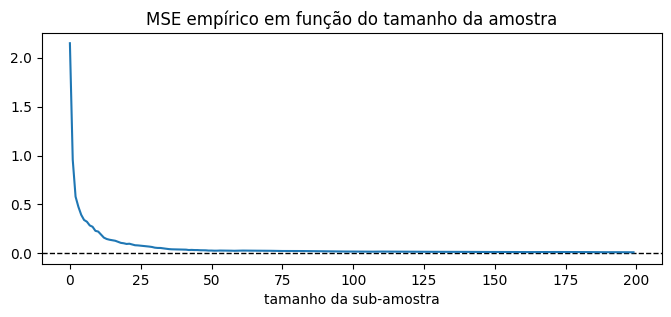

In [9]:
mse_empirico = np.sum(np.power(estimativas - θ, 2), axis=0)/100

fig, ax = plt.subplots(figsize=(8,3))
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax.plot(np.arange(len(mse_empirico)), mse_empirico)
ax.set_title('MSE empírico em função do tamanho da amostra')
ax.set_xlabel('tamanho da sub-amostra')
plt.show()

## item c)
Usando as 100 sub-amostras, faça um gráfico para evidenciar a consistência
(ou não) do estimador. Justifique suas escolhas com relação ao conceito de
consistência.

In [10]:
estimativas_completas = estimativas[:,-1]

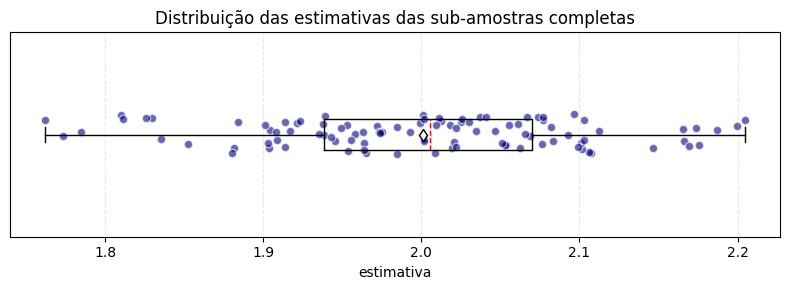

In [11]:
fig, ax = plt.subplots(figsize=(8,3))
jitter = rng.uniform(-0.1, 0.1, size=n_samples)

ax.scatter(
    estimativas_completas, np.ones_like(estimativas_completas) + jitter,
    alpha=0.6, color='navy', edgecolor='white'
)
ax.boxplot(
    estimativas_completas, vert=False, showmeans=True,
    meanprops=dict(marker='d', markerfacecolor='white', markeredgecolor='black'),
    medianprops=dict(color='red', linewidth=1, linestyle='--')
)
ax.set_title('Distribuição das estimativas das sub-amostras completas')
ax.set_yticks([])
ax.set_xlabel('estimativa')

plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## item d)
Construa um intervalo de confiança para o parâmetro, aplique-o para cada sub-
amostra e contabilize o porcentual de vezes que o IC contém o parâmetro de
interesse.

![Gráfico bonito](img/3d.jpg)

![Gráfico bonito](img/3d_ii.jpg)

In [12]:
def calcula_ic(α, samples):
    z_alpha = norm.ppf(1-α/2)
    lower_bound = np.mean(samples, axis=1) / (
        2 + z_alpha/(
            pow(samples.shape[1]/2, 0.5)
        )
    ) 
    upper_bound = np.mean(samples, axis=1) / (
        2 - z_alpha/(
            pow(samples.shape[1]/2, 0.5)
        )
    ) 
    return lower_bound, upper_bound

In [13]:
α = 0.05
lower_bound, upper_bound = calcula_ic(α, samples)
out_of_bounds = (θ < lower_bound) | (θ > upper_bound)

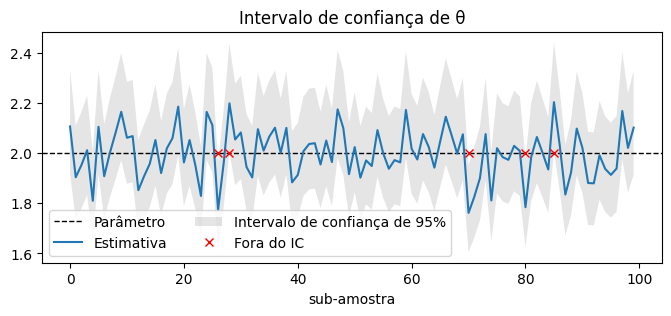

In [14]:
fig, ax = plt.subplots(figsize=(8,3))
ax.axhline(y=θ, color='black', linestyle='--', linewidth=1, label='Parâmetro')
ax.plot(np.arange(n_samples), estimativas_completas, label='Estimativa')
ax.fill_between(
    np.arange(n_samples), 
    lower_bound, upper_bound, 
    facecolor="black", alpha=0.1,
    label = 'Intervalo de confiança de 95%'
)
ax.plot(
    np.arange(n_samples)[out_of_bounds], [2]*np.sum(out_of_bounds), 
    'x', color='red', label='Fora do IC'
)
ax.set_title('Intervalo de confiança de θ')
ax.set_xlabel('sub-amostra')
ax.legend(ncols=2, loc='best')
plt.show()

## item e)
Desenvolva um teste de hipóteses para determinar se a proporção observada
no item (e) é igual à prevista (o nível de confiança).

![Gráfico bonito](img/3e.jpg)

In [66]:
def calcula_estatistica_de_teste(sample, p0, α=0.05):
    estimativa = np.mean(sample)
    z = (estimativa - p0) / pow(
            p0*(1-p0)/len(sample), 0.5
        )
    z_alpha = stats.norm.ppf(1-α/2)
    p_value = 2*(1 - stats.norm.cdf(x=abs(z)))
    return z, z_alpha, p_value

In [67]:
calcula_estatistica_de_teste(out_of_bounds, p0=α, α=0.05)

(0.0, 1.959963984540054, 1.0)

# Questão 4
Crie duas amostras aleatórias independentes de duas distribuições normais de
médias diferentes mas de mesma variância, de tamanhos 100 e 200,
respectivamente.

In [20]:
μ1, μ2, σ = 15, 64, 5
samples = [
    rng.normal(loc=μ1, scale=σ, size=100),
    rng.normal(loc=μ2, scale=σ, size=200)
]

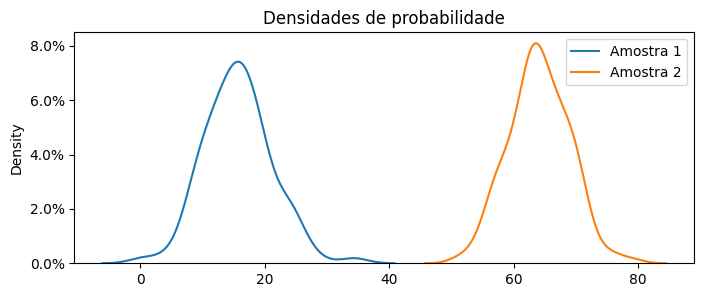

In [27]:
fig, ax = plt.subplots(figsize=(8,3))

sns.kdeplot(samples[0], ax=ax, label='Amostra 1')
sns.kdeplot(samples[1], ax=ax, label='Amostra 2')
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_title('Densidades de probabilidade')
ax.legend()
plt.show()

## item f)
Desenvolva um teste para verificar se as variâncias são iguais.

In [74]:
def calcula_estatistica_de_teste(samples, α=0.05):
    μ1_hat, μ2_hat = np.mean(samples[0]), np.mean(samples[1])
    n1, n2 = samples[0].shape[0], samples[1].shape[0]
    
    S1 = np.sum(
        np.power(samples[0] - μ1_hat, 2)
    ) / (n1-1)
    S2 = np.sum(
        np.power(samples[1] - μ2_hat, 2)
    ) / (n2-1)
    
    F = S1/S2
    F_alpha = (
        stats.f.ppf(q = α/2, dfn = n1-1, dfd = n2-1),
        stats.f.ppf(q = 1-α/2, dfn = n1-1, dfd = n2-1)
    )
    return F, F_alpha

In [75]:
F, bounds = calcula_estatistica_de_teste(samples, α=0.05)
F, bounds

(1.2241849774905982, (0.7029624974905669, 1.394503483210134))

## item g)
Calcule o p-valor.

In [72]:
def calcula_p_valor(F, n1, n2):
    if F<1:
        p_valor = 2*stats.f.cdf(x=F, dfn=n1-1, dfd=n2-1)
    else:
        p_valor = 2*(1 - stats.f.cdf(x=F, dfn=n1-1, dfd=n2-1))
    return p_valor

In [73]:
calcula_p_valor(F, n1=samples[0].shape[0], n2=samples[1].shape[0])

0.23297290618809607

## item h) 
Plote a curva característica do teste do item (a) como uma função de $ \lambda = \frac{\sigma^2_1}{\sigma^2_2}$

In [84]:
def calcula_erro_tipo_ii(bounds, n1, n2, λ):
    lower, upper = bounds[0]/λ, bounds[1]/λ
    β = (
        stats.f.cdf(x=upper, dfn=n1-1, dfd=n2-1) -
        stats.f.cdf(x=lower, dfn=n1-1, dfd=n2-1)
    )
    return β

In [83]:
calcula_erro_tipo_ii(bounds, n1=samples[0].shape[0], n2=samples[1].shape[0], λ=1)

0.95

In [94]:
θ1 = np.arange(0.1, 5.1, 0.1)
β = []
for λ in θ1: 
    β.append(
        calcula_erro_tipo_ii(bounds, 
                             n1=samples[0].shape[0], 
                             n2=samples[1].shape[0], 
                             λ=λ)
    )

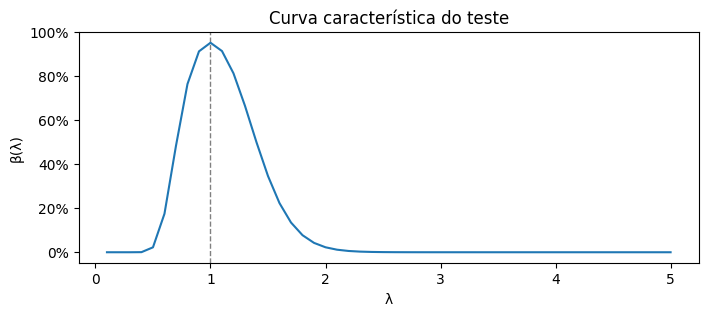

In [107]:
fig, ax = plt.subplots(figsize=(8,3))
ax.axvline(x=1, color='gray', linestyle='--', linewidth=1)
ax.plot(θ1, β)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_title('Curva característica do teste')
ax.set_ylabel('β(λ)')
ax.set_xlabel('λ')
ax.set_ylim(top=1)
plt.show()

## item i) 
Determine a probabilidade de erro tipo II do teste do item (a) se a razão entre
as variâncias é $ \frac{\sigma^2_1}{\sigma^2_2} = r$? Escolha r.

In [108]:
r = 1.5
calcula_erro_tipo_ii(bounds, n1=samples[0].shape[0], n2=samples[1].shape[0], λ=r)

0.3455445634622184

## item j) [TODO]
Considerando as duas amostras de mesmo tamanho, qual seria o tamanho
mínimo para detectar que $ \frac{\sigma^2_1}{\sigma^2_2} > r$ com pelo menos 90% de probabilidade?

## item k) [TODO]
Desenvolva um experimento de simulação para verificar empiricamente
esse resultado.

# Questão 5
Considere duas amostras aleatórias independentes de duas distribuições normais
com médias e variâncias desconhecidas com tamanhos 100 e 200.

## item l) 
Escreva um teste de razão de verossimilhança para igualdade das médias.   
i. Calcule uma expressão para a estatística de teste   
ii. Determine a regra de rejeição considerando a distribuição assintótica da
estatística de teste.

## item m) 
Usando simulação de Monte Carlo, obtenha um grande número de replicações
das duas amostras fazendo as duas médias iguais, porém com variâncias
diferentes.

## item n) 
Aplique o teste para cada replicação anotando: o valor da estatística de teste e
o resultado do teste (rejeição ou não).

## item o) 
Compare as distribuições empírica e teórica da estatística de teste.

## item p) 
Verifique o porcentual de vezes em que o teste foi rejeitado e compare com o
valor teórico dados pela distribuição assintótica da estatística de teste. O que
se pode dizer ?

# Questão 6
Considere um modelo de regressão linear simples expresso por
$ y_i = \beta_0 + \beta_1x_i + \varepsilon_i, i=1,...,n
$, com os $ \varepsilon_i \sim N(0,\sigma^2)$ independentes entre si e dos
valores de 𝑥3.
## a) 
Estabeleça valores para os parâmetros populacionais do modelo: $ \beta_0, \beta_1 $ e $\sigma^2$.
## b) 
Apresente os estimadores não viesados de $ \beta_0, \beta_1 $ e $\sigma^2$ . Explique como são
obtidos. Use um mínimo de equações.
## c) 
Crie uma amostra aleatória de uma Normal de tamanho n <=30. Esses serão os
valores $ x_i, i=1,...,n $.